# Integração — Rios x Preços (Região Norte, mensal)

Junta os dados **já tratados** dos dois notebooks de aquisição (`notebook_dados_rios.ipynb` e `notebook_dados_precos.ipynb`) numa chave comum: **UF + mês (`AnoMes`)**, cobrindo os 7 estados da Região Norte (AC, AM, AP, PA, RO, RR, TO).

**Fontes usadas:**
- Rios: `Dados_nivel_rios/Dados Tratados/cotas_tratado.csv`
- CONAB/Prohort: `Dados_precos/Dados Tratados/Preos-agropecurios-Mensal-UF_Norte.csv`, `Prohort-Mensal_Norte.csv`
- ANP: `Dados_precos/Dados Tratados/anp_slp_serie_semanal_municipio.csv`, `anp_slp_serie_semanal_regional.csv`

**Fora do escopo (por decisão explícita):**
- **ANTAQ** (carga portuária) — só cobre o Amazonas, fica de fora por enquanto.
- **IPCA (IBGE)** — o notebook de preços só salva o JSON bruto do IPCA; o `df_ipca` limpo nunca é persistido em CSV, então não há arquivo tratado pra usar aqui.
- **`Preos-Mnimos_Norte.csv`** — preço mínimo de política pública (não é preço de mercado), varia por período de vigência em vez de por mês; fora do escopo deste notebook.

**Saídas** (pasta `Tabelas/`, na raiz do projeto):
1. `painel_mensal_rios_anp.csv` — 1 linha por (uf, AnoMes): rio + preços de combustível (wide).
2. `rios_conab_mensal.csv` — 1 linha por (uf, AnoMes, produto CONAB): rio repetido por produto (long).
3. `rios_prohort_mensal.csv` — 1 linha por (uf, AnoMes, produto Prohort): rio repetido por produto (long).
4. `mega_tabela_integrada_mensal.csv` — todas as fontes de preço empilhadas num formato comum (`fonte, produto, valor`), com o rio já junto.
5. `proveniencia_integracao.json` — documentação do join: chaves usadas, decisões e contagem de linhas.

In [10]:
import pandas as pd
import numpy as np
import os
import json
from pathlib import Path
from datetime import datetime

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

RIOS_TRATADOS = Path("Dados_nivel_rios") / "Dados Tratados"
PRECOS_TRATADOS = Path("Dados_precos") / "Dados Tratados"
TABELAS = Path("Tabelas")
TABELAS.mkdir(exist_ok=True)

print("Data/hora da integração:", datetime.now().isoformat(timespec="seconds"))


Data/hora da integração: 2026-09-13T20:10:34


## A. Painel-base mensal de rios, por UF

Agrega `cotas_tratado.csv` (diário, por estação) para **1 linha por (uf, AnoMes)**, cobrindo as 7 UFs — não só Manaus/AM. Estados com mais de uma estação (ex. AM tem 5) entram como média entre as estações daquele estado naquele mês; `n_estacoes` documenta quantas estações contribuíram, para transparência.

In [11]:
df_rios = pd.read_csv(
    RIOS_TRATADOS / "cotas_tratado.csv",
    usecols=["data", "codigo_estacao", "cota_cm", "uf"],
    dtype={"codigo_estacao": str},
    parse_dates=["data"],
)
df_rios["AnoMes"] = df_rios["data"].dt.strftime("%Y-%m")

rio_mensal_uf = (
    df_rios.groupby(["uf", "AnoMes"], as_index=False)
    .agg(
        cota_media_cm=("cota_cm", "mean"),
        cota_max_cm=("cota_cm", "max"),
        cota_min_cm=("cota_cm", "min"),
        n_estacoes=("codigo_estacao", "nunique"),
        n_dias=("cota_cm", "count"),
    )
    .sort_values(["uf", "AnoMes"])
    .reset_index(drop=True)
)

n_uf_rio = rio_mensal_uf["uf"].nunique()
print(f"rio_mensal_uf: {len(rio_mensal_uf)} linhas, {n_uf_rio} UFs, "
      f"{rio_mensal_uf['AnoMes'].min()} a {rio_mensal_uf['AnoMes'].max()}")
rio_mensal_uf.head(10)


rio_mensal_uf: 316 linhas, 7 UFs, 2021-01 a 2026-09


,uf,AnoMes,cota_media_cm,cota_max_cm,cota_min_cm,n_estacoes,n_dias
0,AC,2021-01,970.930108,1285.0,662.5,3,93
1,AC,2021-02,1277.458333,1708.0,932.0,3,84
2,AC,2021-03,1050.129032,1368.0,708.0,3,93
3,AC,2021-04,949.927778,1246.0,718.0,3,90
4,AC,2021-05,448.397849,904.0,244.0,3,93
5,AC,2021-06,286.360294,479.0,187.5,3,68
6,AC,2021-07,175.478495,270.0,111.0,3,93
7,AC,2021-08,144.155914,182.0,97.0,3,93
8,AC,2021-09,120.905556,177.5,86.5,3,90
9,AC,2021-10,139.397849,250.0,71.0,3,93


## B. Painel mensal + ANP (combustíveis) — formato wide

ANP tem poucos produtos (combustíveis: ~4-5 tipos), então cabe em colunas sem gerar fan-out. Duas séries:
- `anp_slp_serie_semanal_municipio.csv` — semanal, por UF+município+produto → agregada aqui pra mensal, por UF.
- `anp_slp_serie_semanal_regional.csv` — semanal, **Região Norte inteira** (sem UF) → referência macro, entra igual em todas as UFs daquele mês.

Resultado (`painel_mensal_rios_anp`) continua 1 linha por (uf, AnoMes) — nenhuma duplicação.

In [12]:
anp_sem_municipio = pd.read_csv(PRECOS_TRATADOS / "anp_slp_serie_semanal_municipio.csv")
anp_sem_municipio["AnoMes"] = pd.to_datetime(anp_sem_municipio["SEMANA"]).dt.strftime("%Y-%m")

anp_mensal_uf = (
    anp_sem_municipio.groupby(["ESTADO_SIGLA", "AnoMes", "PRODUTO"], as_index=False)["preco_medio"]
    .mean()
    .pivot_table(index=["ESTADO_SIGLA", "AnoMes"], columns="PRODUTO", values="preco_medio")
    .reset_index()
    .rename(columns={"ESTADO_SIGLA": "uf"})
)
anp_mensal_uf.columns = [
    c if c in ("uf", "AnoMes") else f"anp_preco_{str(c).lower().replace(' ', '_')}"
    for c in anp_mensal_uf.columns
]

painel_mensal = rio_mensal_uf.merge(anp_mensal_uf, on=["uf", "AnoMes"], how="left")

# Série regional (Norte inteiro, sem UF) — mesma referência pra todas as UFs daquele mês
anp_regional = pd.read_csv(PRECOS_TRATADOS / "anp_slp_serie_semanal_regional.csv")
anp_regional["AnoMes"] = pd.to_datetime(anp_regional["SEMANA"]).dt.strftime("%Y-%m")
anp_regional_mensal = (
    anp_regional.groupby(["AnoMes", "PRODUTO"], as_index=False)["preco_medio"]
    .mean()
    .pivot_table(index="AnoMes", columns="PRODUTO", values="preco_medio")
    .reset_index()
)
anp_regional_mensal.columns = ["AnoMes"] + [
    f"anp_regional_{str(c).lower().replace(' ', '_')}" for c in anp_regional_mensal.columns[1:]
]

painel_mensal = painel_mensal.merge(anp_regional_mensal, on="AnoMes", how="left")

caminho_painel = TABELAS / "painel_mensal_rios_anp.csv"
painel_mensal.to_csv(caminho_painel, index=False)
print(f"[SALVO] {caminho_painel} — {len(painel_mensal)} linhas, {painel_mensal['uf'].nunique()} UFs")
painel_mensal.head(10)


[SALVO] Tabelas\painel_mensal_rios_anp.csv — 316 linhas, 7 UFs


,uf,AnoMes,cota_media_cm,cota_max_cm,cota_min_cm,n_estacoes,n_dias,anp_preco_diesel,anp_preco_diesel_s10,anp_preco_etanol,anp_preco_gasolina,anp_preco_gasolina_aditivada,anp_preco_glp,anp_preco_gnv,anp_regional_diesel,anp_regional_diesel_s10,anp_regional_etanol,anp_regional_gasolina,anp_regional_gasolina_aditivada,anp_regional_glp,anp_regional_gnv
0,AC,2021-01,970.930108,1285.0,662.5,3,93,4.686847,4.732949,4.046467,5.268687,5.325442,93.886188,NaN,4.030636,4.097939,3.738494,4.625922,4.808965,88.528512,3.49000
1,AC,2021-02,1277.458333,1708.0,932.0,3,84,4.966420,5.004869,4.208337,5.652585,5.739180,98.531179,NaN,4.291451,4.328451,3.960661,5.037741,5.208335,91.320043,3.58000
2,AC,2021-03,1050.129032,1368.0,708.0,3,93,5.495517,5.516772,5.382886,6.306353,6.371437,103.440050,NaN,4.687719,4.669514,4.568026,5.536911,5.712585,94.500334,3.83375
3,AC,2021-04,949.927778,1246.0,718.0,3,90,5.414535,5.440885,5.514267,6.405361,6.434885,104.920999,NaN,4.669681,4.655813,4.614923,5.633851,5.796382,96.057210,3.81500
4,AC,2021-05,448.397849,904.0,244.0,3,93,5.720597,5.754900,5.670376,6.551505,6.589913,105.608268,NaN,4.854628,4.866521,4.802564,5.645795,5.805126,96.496083,3.72400
5,AC,2021-06,286.360294,479.0,187.5,3,68,5.758179,5.792745,5.818935,6.577169,6.612936,106.481055,NaN,4.878190,4.887618,4.946634,5.708289,5.837270,98.224011,3.79000
6,AC,2021-07,175.478495,270.0,111.0,3,93,5.799059,5.831547,5.845989,6.617801,6.659755,111.524248,NaN,4.966498,4.967964,5.133784,5.925335,6.050995,102.751945,3.79000
7,AC,2021-08,144.155914,182.0,97.0,3,93,5.816683,5.850260,5.914242,6.692115,6.742849,112.874709,NaN,4.988971,5.004859,5.249375,6.034722,6.170653,104.332505,3.99000
8,AC,2021-09,120.905556,177.5,86.5,3,90,5.845863,5.869783,6.041693,6.753569,6.802014,114.516304,NaN,5.102039,5.115282,5.381359,6.162295,6.281800,106.529425,3.99000
9,AC,2021-10,139.397849,250.0,71.0,3,93,6.053354,6.072051,6.144822,6.905527,6.956371,116.829792,NaN,5.375067,5.389165,5.460208,6.369576,6.484619,108.749498,3.99000


## C1. Rios x CONAB (preços agropecuários) — formato long

`Preos-agropecurios-Mensal-UF_Norte.csv` já vem mensal, por UF, mas com **muitos produtos distintos** (alta cardinalidade) — não cabe em colunas. Mantido em formato longo: 1 linha por (uf, AnoMes, produto), com as estatísticas do rio repetidas para cada produto daquele uf/mês (fan-out esperado, não é bug — não tratar essas linhas como observações independentes numa correlação sem antes agregar ou pivotar por produto).

In [13]:
conab_mensal = pd.read_csv(PRECOS_TRATADOS / "Preos-agropecurios-Mensal-UF_Norte.csv")
conab_mensal["AnoMes"] = (
    conab_mensal["ano"].astype(int).astype(str) + "-" + conab_mensal["mes"].astype(int).astype(str).str.zfill(2)
)

rios_conab_mensal = rio_mensal_uf.merge(conab_mensal, on=["uf", "AnoMes"], how="inner")

caminho_conab = TABELAS / "rios_conab_mensal.csv"
rios_conab_mensal.to_csv(caminho_conab, index=False)
print(f"[SALVO] {caminho_conab} — {len(rios_conab_mensal)} linhas, "
      f"{rios_conab_mensal['produto'].nunique()} produtos distintos, "
      f"{rios_conab_mensal['uf'].nunique()} UFs")
rios_conab_mensal.head(10)


[SALVO] Tabelas\rios_conab_mensal.csv — 1566 linhas, 112 produtos distintos, 7 UFs


,uf,AnoMes,cota_media_cm,cota_max_cm,cota_min_cm,n_estacoes,n_dias,produto,classificao_produto,id_produto,regiao,ano,mes,dsc_nivel_comercializacao,valor_produto_kg
0,AC,2025-09,85.211111,254.0,18.0,3,90,ABACAXI,PÉROLA,6320,NORTE,2025,9,PREÇO RECEBIDO P/ PRODUTOR,2.85
1,AC,2025-09,85.211111,254.0,18.0,3,90,ACAI,FRUTO,8623,NORTE,2025,9,PREÇO RECEBIDO P/ PRODUTOR,1.97
2,AC,2025-09,85.211111,254.0,18.0,3,90,ACUCAR,CRISTAL,4218,NORTE,2025,9,ATACADO,3.56
3,AC,2025-09,85.211111,254.0,18.0,3,90,ACUCAR,CRISTAL,4218,NORTE,2025,9,VAREJO,4.15
4,AC,2025-09,85.211111,254.0,18.0,3,90,ARROZ,LONGO FINO TIPO 1 BE,4693,NORTE,2025,9,VAREJO,5.10
5,AC,2025-09,85.211111,254.0,18.0,3,90,ARROZ,LONGO FINO TIPO 1 BE,4693,NORTE,2025,9,ATACADO,4.23
6,AC,2025-09,85.211111,254.0,18.0,3,90,BANANA,PRATA,4629,NORTE,2025,9,VAREJO,8.02
7,AC,2025-09,85.211111,254.0,18.0,3,90,BANANA,NANICA,4627,NORTE,2025,9,VAREJO,1.36
8,AC,2025-09,85.211111,254.0,18.0,3,90,BANANA,NANICA,4627,NORTE,2025,9,VAREJO,9.04
9,AC,2025-09,85.211111,254.0,18.0,3,90,BANANA,PRATA,4629,NORTE,2025,9,PREÇO RECEBIDO P/ PRODUTOR,1.89


## C2. Rios x Prohort (preços em CEASA) — formato long

`Prohort-Mensal_Norte.csv` tem **duas** colunas de UF: `uf_origem_produto` (onde o produto foi produzido) e `uf_ceasa` (onde foi vendido no mercado atacadista). O filtro do notebook de preços inclui uma linha se **qualquer uma das duas** for do Norte — então pode haver linha com origem no Norte mas CEASA fora (ou vice-versa).

**Decisão:** usar `uf_origem_produto` como a UF de interesse. Faz mais sentido fisicamente ligar o nível do rio (cheia/seca) à produção/escoamento *daquele* estado do que ao estado onde o produto terminou sendo vendido.

In [14]:
prohort_mensal = pd.read_csv(PRECOS_TRATADOS / "Prohort-Mensal_Norte.csv")
prohort_mensal = prohort_mensal.rename(columns={"uf_origem_produto": "uf"})
prohort_mensal["AnoMes"] = (
    prohort_mensal["id_ano_comercializacao"].astype(int).astype(str) + "-"
    + prohort_mensal["id_mes_comercializacao"].astype(int).astype(str).str.zfill(2)
)

# Mantém só linhas cuja UF de ORIGEM é de fato uma das 7 UFs do Norte
# (algumas linhas entraram no recorte só por causa da UF do CEASA, não da origem).
ufs_norte = {"AC", "AM", "AP", "PA", "RO", "RR", "TO"}
n_antes = len(prohort_mensal)
prohort_mensal = prohort_mensal[prohort_mensal["uf"].isin(ufs_norte)].copy()
print(f"Prohort-Mensal: {n_antes} -> {len(prohort_mensal)} linhas após restringir a uf_origem_produto no Norte "
      f"({n_antes - len(prohort_mensal)} linhas tinham só a UF do CEASA no Norte, não a origem)")

rios_prohort_mensal = rio_mensal_uf.merge(prohort_mensal, on=["uf", "AnoMes"], how="inner")

caminho_prohort = TABELAS / "rios_prohort_mensal.csv"
rios_prohort_mensal.to_csv(caminho_prohort, index=False)
print(f"[SALVO] {caminho_prohort} — {len(rios_prohort_mensal)} linhas, "
      f"{rios_prohort_mensal['dsc_produto'].nunique()} produtos distintos, "
      f"{rios_prohort_mensal['uf'].nunique()} UFs")
rios_prohort_mensal.head(10)


Prohort-Mensal: 19781 -> 16990 linhas após restringir a uf_origem_produto no Norte (2791 linhas tinham só a UF do CEASA no Norte, não a origem)
[SALVO] Tabelas\rios_prohort_mensal.csv — 10440 linhas, 292 produtos distintos, 7 UFs


,uf,AnoMes,cota_media_cm,cota_max_cm,cota_min_cm,n_estacoes,n_dias,id_ano_comercializacao,id_mes_comercializacao,municipio_origem_produto,cod_ibge_municipio_origem_produto,dsc_ceasa,uf_ceasa,municipio_ceasa,cod_ibge_municipio_ceasa,dsc_produto,qtd_comercializada_kg,valor_comercializado,pais_origem
0,AC,2021-08,144.155914,182.0,97.0,3,93,2021,8,MARECHAL THAUMATURGO-AC,1200351,CEASA/PE - RECIFE,PE,RECIFE-PE,2611606,OUTROS GENEROS,1495,26087.75,Brasil
1,AC,2021-08,144.155914,182.0,97.0,3,93,2021,8,RIO BRANCO-AC,1200401,CEASA/AC - RIO BRANCO,AC,RIO BRANCO-AC,1200401,TANGERINA PONKAN,20,49.90,Brasil
2,AC,2021-08,144.155914,182.0,97.0,3,93,2021,8,SENADOR GUIOMARD-AC,1200450,CEASA/AC - RIO BRANCO,AC,RIO BRANCO-AC,1200401,SALSA,14,200.06,Brasil
3,AC,2021-08,144.155914,182.0,97.0,3,93,2021,8,RIO BRANCO-AC,1200401,CEASA/AC - RIO BRANCO,AC,RIO BRANCO-AC,1200401,SALSA,55,785.95,Brasil
4,AC,2021-08,144.155914,182.0,97.0,3,93,2021,8,PORTO ACRE-AC,1200807,CEASA/AC - RIO BRANCO,AC,RIO BRANCO-AC,1200401,SALSA,21,300.09,Brasil
5,AC,2021-08,144.155914,182.0,97.0,3,93,2021,8,SENADOR GUIOMARD-AC,1200450,CEASA/AC - RIO BRANCO,AC,RIO BRANCO-AC,1200401,RUCULA,327,2181.09,Brasil
6,AC,2021-08,144.155914,182.0,97.0,3,93,2021,8,RIO BRANCO-AC,1200401,CEASA/AC - RIO BRANCO,AC,RIO BRANCO-AC,1200401,RUCULA,613,4088.71,Brasil
7,AC,2021-08,144.155914,182.0,97.0,3,93,2021,8,PORTO ACRE-AC,1200807,CEASA/AC - RIO BRANCO,AC,RIO BRANCO-AC,1200401,RUCULA,82,546.94,Brasil
8,AC,2021-08,144.155914,182.0,97.0,3,93,2021,8,RIO BRANCO-AC,1200401,CEASA/AC - RIO BRANCO,AC,RIO BRANCO-AC,1200401,QUIABO,1475,6150.01,Brasil
9,AC,2021-08,144.155914,182.0,97.0,3,93,2021,8,RIO BRANCO-AC,1200401,CEASA/AC - RIO BRANCO,AC,RIO BRANCO-AC,1200401,QUEIJO,1504,4512.00,Brasil


## D. Mega-tabela consolidada (todas as fontes empilhadas)

Formato comum (`uf, AnoMes, fonte, produto, valor, unidade`) para as 3 fontes de preço (CONAB, Prohort, ANP), com as estatísticas do rio já junto em cada linha. `fonte` permite filtrar de volta pra reconstruir cada tabela individual, ou usar direto pra uma visão cross-source (ex. `groupby(["uf","fonte"])`, um facetado por fonte).

In [15]:
def para_formato_comum(df, fonte, col_produto, col_valor, col_unidade=None, extra=None):
    out = pd.DataFrame({
        "uf": df["uf"].values,
        "AnoMes": df["AnoMes"].values,
        "fonte": fonte,
        "produto": df[col_produto].values,
        "valor": df[col_valor].values,
        "unidade": df[col_unidade].values if col_unidade else pd.NA,
    })
    if extra:
        for novo, original in extra.items():
            out[novo] = df[original].values
    return out

partes_long = [
    para_formato_comum(
        conab_mensal.rename(columns={"uf": "uf"}), "CONAB_agropecuario",
        "produto", "valor_produto_kg",
        extra={"nivel_comercializacao": "dsc_nivel_comercializacao"},
    ),
    para_formato_comum(
        prohort_mensal, "Prohort_CEASA",
        "dsc_produto", "valor_comercializado",
    ),
    para_formato_comum(
        anp_sem_municipio.rename(columns={"ESTADO_SIGLA": "uf"}), "ANP_combustivel",
        "PRODUTO", "preco_medio",
    ),
]

precos_long = pd.concat(partes_long, ignore_index=True)

mega_tabela = rio_mensal_uf.merge(precos_long, on=["uf", "AnoMes"], how="left")

caminho_mega = TABELAS / "mega_tabela_integrada_mensal.csv"
mega_tabela.to_csv(caminho_mega, index=False)
print(f"[SALVO] {caminho_mega} — {len(mega_tabela)} linhas")
print(mega_tabela["fonte"].value_counts(dropna=False))
mega_tabela.head(10)


[SALVO] Tabelas\mega_tabela_integrada_mensal.csv — 32249 linhas
fonte
ANP_combustivel       20236
Prohort_CEASA         10440
CONAB_agropecuario     1566
NaN                       7
Name: count, dtype: int64


,uf,AnoMes,cota_media_cm,cota_max_cm,cota_min_cm,n_estacoes,n_dias,fonte,produto,valor,unidade,nivel_comercializacao
0,AC,2021-01,970.930108,1285.0,662.5,3,93,ANP_combustivel,DIESEL,5.240000,<NA>,NaN
1,AC,2021-01,970.930108,1285.0,662.5,3,93,ANP_combustivel,DIESEL S10,5.260000,<NA>,NaN
2,AC,2021-01,970.930108,1285.0,662.5,3,93,ANP_combustivel,GASOLINA,5.939000,<NA>,NaN
3,AC,2021-01,970.930108,1285.0,662.5,3,93,ANP_combustivel,GASOLINA ADITIVADA,5.935000,<NA>,NaN
4,AC,2021-01,970.930108,1285.0,662.5,3,93,ANP_combustivel,GLP,91.250000,<NA>,NaN
5,AC,2021-01,970.930108,1285.0,662.5,3,93,ANP_combustivel,DIESEL,4.537320,<NA>,NaN
6,AC,2021-01,970.930108,1285.0,662.5,3,93,ANP_combustivel,DIESEL,4.556188,<NA>,NaN
7,AC,2021-01,970.930108,1285.0,662.5,3,93,ANP_combustivel,DIESEL,4.542850,<NA>,NaN
8,AC,2021-01,970.930108,1285.0,662.5,3,93,ANP_combustivel,DIESEL,4.557880,<NA>,NaN
9,AC,2021-01,970.930108,1285.0,662.5,3,93,ANP_combustivel,DIESEL S10,4.590148,<NA>,NaN


## Proveniência da integração

In [16]:
proveniencia = {
    "etapa": "Integração mensal rios x preços (Região Norte)",
    "data_processamento": datetime.now().isoformat(),
    "chave_de_join": ["uf", "AnoMes (YYYY-MM)"],
    "fontes": {
        "rios": str(RIOS_TRATADOS / "cotas_tratado.csv"),
        "anp_semanal_municipio": str(PRECOS_TRATADOS / "anp_slp_serie_semanal_municipio.csv"),
        "anp_semanal_regional": str(PRECOS_TRATADOS / "anp_slp_serie_semanal_regional.csv"),
        "conab_mensal_uf": str(PRECOS_TRATADOS / "Preos-agropecurios-Mensal-UF_Norte.csv"),
        "prohort_mensal": str(PRECOS_TRATADOS / "Prohort-Mensal_Norte.csv"),
    },
    "excluidos_deste_escopo": {
        "ANTAQ": "só cobre o Amazonas (SGUF fixo em 'AM'); não incluído por instrução explícita do usuário.",
        "IPCA": "notebook de preços só salva o JSON bruto do IPCA; df_ipca limpo nunca é persistido em CSV.",
        "Preos-Mnimos_Norte.csv": "preço mínimo de política pública (não de mercado), varia por período de vigência, não por mês.",
    },
    "decisoes": [
        "Rios agregados por (uf, AnoMes) usando média/máx/mín de cota_cm entre todas as estações daquela UF naquele mês.",
        "ANP: poucos produtos -> pivotado para wide (uma coluna por combustível), sem fan-out.",
        "CONAB e Prohort: muitos produtos -> mantidos em formato long (uma linha por produto), rio repetido por produto.",
        "Prohort-Mensal: usada a UF de ORIGEM do produto (uf_origem_produto), não a UF do CEASA (uf_ceasa), "
        "e linhas cuja origem não é do Norte foram descartadas mesmo se o CEASA fosse do Norte.",
    ],
    "resultado": {
        "rio_mensal_uf": {"linhas": len(rio_mensal_uf), "ufs": int(rio_mensal_uf["uf"].nunique())},
        "painel_mensal_rios_anp": {"linhas": len(painel_mensal)},
        "rios_conab_mensal": {"linhas": len(rios_conab_mensal), "produtos": int(rios_conab_mensal["produto"].nunique())},
        "rios_prohort_mensal": {"linhas": len(rios_prohort_mensal), "produtos": int(rios_prohort_mensal["dsc_produto"].nunique())},
        "mega_tabela_integrada_mensal": {"linhas": len(mega_tabela)},
    },
}

with open(TABELAS / "proveniencia_integracao.json", "w", encoding="utf-8") as f:
    json.dump(proveniencia, f, ensure_ascii=False, indent=2, default=str)

print("[SALVO] Tabelas/proveniencia_integracao.json")
print(json.dumps(proveniencia["resultado"], indent=2, ensure_ascii=False))


[SALVO] Tabelas/proveniencia_integracao.json
{
  "rio_mensal_uf": {
    "linhas": 316,
    "ufs": 7
  },
  "painel_mensal_rios_anp": {
    "linhas": 316
  },
  "rios_conab_mensal": {
    "linhas": 1566,
    "produtos": 112
  },
  "rios_prohort_mensal": {
    "linhas": 10440,
    "produtos": 292
  },
  "mega_tabela_integrada_mensal": {
    "linhas": 32249
  }
}


## Verificação rápida

Checagem de sanidade antes de qualquer análise/correlação formal.

In [17]:
print("=== rio_mensal_uf ===")
print(f"UFs: {sorted(rio_mensal_uf['uf'].unique())}")
print(f"Período: {rio_mensal_uf['AnoMes'].min()} a {rio_mensal_uf['AnoMes'].max()}")

print("\n=== mega_tabela: linhas por fonte ===")
print(mega_tabela["fonte"].value_counts(dropna=False))

print("\n=== reconstrução: mega_tabela filtrada por fonte == CONAB deve bater com rios_conab_mensal ===")
n_mega_conab = mega_tabela[mega_tabela["fonte"] == "CONAB_agropecuario"].dropna(subset=["valor"]).shape[0]
print(f"Linhas CONAB na mega-tabela (não nulas): {n_mega_conab} | linhas em rios_conab_mensal: {len(rios_conab_mensal)}")


=== rio_mensal_uf ===
UFs: ['AC', 'AM', 'AP', 'PA', 'RO', 'RR', 'TO']
Período: 2021-01 a 2026-09

=== mega_tabela: linhas por fonte ===
fonte
ANP_combustivel       20236
Prohort_CEASA         10440
CONAB_agropecuario     1566
NaN                       7
Name: count, dtype: int64

=== reconstrução: mega_tabela filtrada por fonte == CONAB deve bater com rios_conab_mensal ===
Linhas CONAB na mega-tabela (não nulas): 1527 | linhas em rios_conab_mensal: 1566


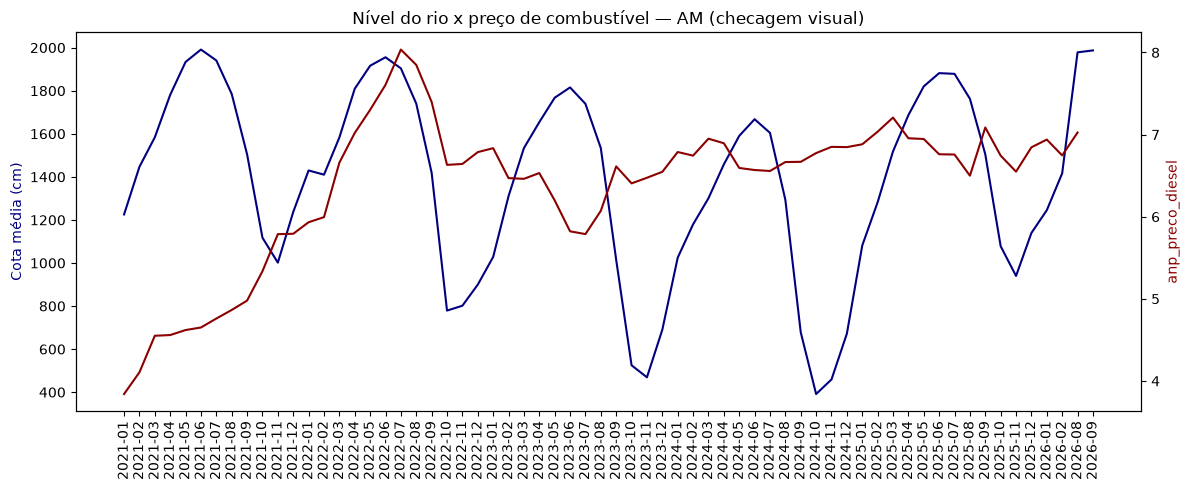

In [18]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 5))
sub = painel_mensal[painel_mensal["uf"] == "AM"].sort_values("AnoMes")

ax1.plot(sub["AnoMes"], sub["cota_media_cm"], color="navy", label="Cota média (cm)")
ax1.set_ylabel("Cota média (cm)", color="navy")
ax1.tick_params(axis="x", rotation=90)

col_diesel = next((c for c in painel_mensal.columns if "diesel" in c.lower()), None)
if col_diesel:
    ax2 = ax1.twinx()
    ax2.plot(sub["AnoMes"], sub[col_diesel], color="darkred", label=col_diesel)
    ax2.set_ylabel(col_diesel, color="darkred")

plt.title("Nível do rio x preço de combustível — AM (checagem visual)")
fig.tight_layout()
plt.show()
